In [2]:
import pandas as pd

# Caminho do arquivo (exemplo: CSV)
caminho_arquivo = "Analise.xlsb"

# Ler a base de dados
df = pd.read_excel(caminho_arquivo)

# Mostrar as primeiras linhas
print(df.head())

   Unnamed: 0 Unnamed: 1 Unnamed: 2 Unnamed: 3  Unnamed: 4 Unnamed: 5  \
0         NaN        NaN    Janeiro        NaN         NaN        NaN   
1         NaN        NaN    Janeiro         26         NaN        NaN   
2         NaN        NaN    Demanda        NaN         NaN       PROD   
3         NaN     SK 269    GEO/REG    Demanda         NaN       Real   
4         NaN  LONG NECK         MG  65538.324         NaN          0   

  Unnamed: 6 Unnamed: 7 Unnamed: 8  Unnamed: 9  ... Unnamed: 14 Unnamed: 15  \
0        NaN        NaN        NaN         NaN  ...         NaN         NaN   
1        NaN        NaN        NaN         NaN  ...         NaN         NaN   
2        NaN        NaN        NaN         NaN  ...         NaN         NaN   
3       WSNP       Real         1W         NaN  ...  Suf. f (d)         NaN   
4          0          0          0         NaN  ...   10.796472         NaN   

  Unnamed: 16 Unnamed: 17 Unnamed: 18  Unnamed: 19 Unnamed: 20    Unnamed: 21  \
0   F

In [3]:
import pandas as pd

arquivo = "Analise.xlsb"

abas = pd.ExcelFile(arquivo, engine="pyxlsb")
print(abas.sheet_names)

['Cenário atual BR', 'Custos de transferência', 'Produção PCP', 'Transferências Programadas', 'Cenário Divulgado', 'Cenário com Nova Demanda']


In [9]:
df_cenario_atual = pd.read_excel(arquivo, sheet_name="Cenário Divulgado", engine="pyxlsb")
df_custos = pd.read_excel(arquivo, sheet_name="Custos de transferência", engine="pyxlsb")
df_producao = pd.read_excel(arquivo, sheet_name="Produção PCP", engine="pyxlsb")

In [10]:
import pandas as pd

arquivo = "Analise.xlsb"

df_cenário_atual = pd.read_excel(
    arquivo,
    sheet_name="Cenário Divulgado",
    engine="pyxlsb"
)

df_custos = pd.read_excel(
    arquivo,
    sheet_name="Custos de transferência",
    engine="pyxlsb"
)

df_produção = pd.read_excel(
    arquivo,
    sheet_name="Produção PCP",
    engine="pyxlsb"
)

In [19]:
df_raw = pd.read_excel(
    arquivo,
    sheet_name="Cenário Divulgado",
    engine="pyxlsb",
    header=None
)

df_w0 = df_raw.iloc[3:9, [1, 2, 3]].copy()

df_w0.columns = ["Produto", "Região", "Demanda"]

df_w0 = df_w0[df_w0["Região"] != "TOTAL"]

df_w0["Semana"] = "W0"

df_w0

semanas = {
    "W0": 3,
    "W1": 12,
    "W2": 25,
    "W3": 38
}

lista = []

for semana, col in semanas.items():
    temp = df_raw.iloc[3:9, [1, 2, col]].copy()
    temp.columns = ["Produto", "Região", "Demanda"]
    temp = temp[temp["Região"] != "TOTAL"]
    temp["Semana"] = semana
    lista.append(temp)

df_final = pd.concat(lista)

df_final.reset_index(drop=True, inplace=True)

df_final

df_final.groupby(["Semana", "Região"])["Demanda"].sum()

Semana  Região     
W0      GEO/REG           Demanda
        Mapapi           2292.912
        NE Norte         2675.178
        NE Sul           2066.364
        NO Araguaia       114.174
        NO Centro        1270.656
W1      GEO/REG          Trânsito
        Mapapi                  0
        NE Norte                0
        NE Sul                  0
        NO Araguaia             0
        NO Centro               0
W2      GEO/REG        Suf. f (d)
        Mapapi           8.920728
        NE Norte        13.666778
        NE Sul          19.356956
        NO Araguaia      0.000598
        NO Centro       -0.960364
W3      GEO/REG           Demanda
        Mapapi           2331.792
        NE Norte         2007.036
        NE Sul           1730.286
        NO Araguaia        96.498
        NO Centro        1290.942
Name: Demanda, dtype: object

In [32]:
df_raw = pd.read_excel(
    arquivo,
    sheet_name="Cenário Divulgado",
    engine="pyxlsb",
    header=None
)

semanas = {
    "W0": 3,
    "W1": 12,
    "W2": 25,
    "W3": 38
}

lista_final = []

produto_atual = None

for i in range(len(df_raw)):

    if pd.notna(df_raw.iloc[i, 1]):
        produto_atual = df_raw.iloc[i, 1]

    if (
        pd.notna(df_raw.iloc[i, 2]) and
        df_raw.iloc[i, 2] not in ["TOTAL"]
    ):

        for semana, col in semanas.items():

            demanda = df_raw.iloc[i, col]

            if pd.notna(demanda):

                lista_final.append([
                    produto_atual,
                    df_raw.iloc[i, 2],
                    semana,
                    demanda
                ])

df_final = pd.DataFrame(
    lista_final,
    columns=["Produto", "Região", "Semana", "Demanda"]
)

df_final["Demanda"] = pd.to_numeric(
    df_final["Demanda"],
    errors="coerce"
)

df_final.head()

df_atual = df_final.copy()
df_novo = df_final.copy()

df_novo.loc[
    (df_novo["Produto"].str.contains("MALZBIER", na=False)) &
    (df_novo["Semana"] == "W0"),
    "Demanda"
] *= 1.30

print(df_final["Produto"].unique())

comparacao = (
    df_final
    .groupby("Semana", as_index=False)["Demanda"].sum()
    .rename(columns={"Demanda": "Demanda Atual"})
    .merge(
        df_final.assign(
            Demanda=lambda x: x["Demanda"] * (
                ((x["Produto"].str.contains("MALZBIER", na=False)) & (x["Semana"] == "W0")) * 0.30 + 1
            )
        )
        .groupby("Semana", as_index=False)["Demanda"].sum()
        .rename(columns={"Demanda": "Demanda Nova"}),
        on="Semana"
    )
    .assign(Variação=lambda x: x["Demanda Nova"] - x["Demanda Atual"])
)

comparacao

[None 'PATAGONIA AMBER LAGER LN355ML CX12'
 'GOOSE ISLAND MIDWAY NAC LN 355ML CX C/12'
 'MALZBIER BRAHMA LN355ML SIX PAC BAND C/4'
 'COLORADO LAGER LN 355ML CX C/12']


,Semana,Demanda Atual,Demanda Nova,Variação
0,W0,55405.062000,59959.789200,4554.7272
1,W1,4500.000000,4500.000000,0.0000
2,W2,267.839604,267.839604,0.0000
3,W3,50470.146000,50470.146000,0.0000


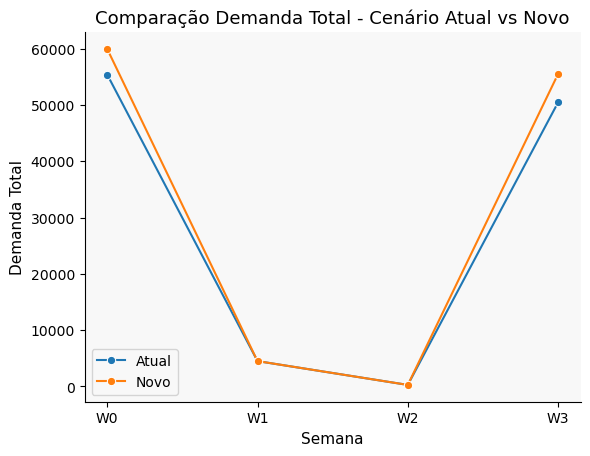

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Criar cenário novo
df_novo = df_final.copy()

# +30% MALZBIER em W0
df_novo.loc[
    (df_novo["Produto"].str.contains("MALZBIER", na=False)) &
    (df_novo["Semana"] == "W0"),
    "Demanda"
] *= 1.30

# +10% total LN a partir de março (W3)
df_novo.loc[
    df_novo["Semana"].isin(["W3"]),
    "Demanda"
] *= 1.10

# Agrupar
demanda_atual = df_final.groupby("Semana")["Demanda"].sum().reset_index()
demanda_nova = df_novo.groupby("Semana")["Demanda"].sum().reset_index()

demanda_atual["Cenário"] = "Atual"
demanda_nova["Cenário"] = "Novo"

df_plot = pd.concat([demanda_atual, demanda_nova])

# Plot
plt.figure()
sns.lineplot(data=df_plot, x="Semana", y="Demanda", hue="Cenário", marker="o")
plt.title("Comparação Demanda Total - Cenário Atual vs Novo")
plt.xlabel("Semana")
plt.ylabel("Demanda Total")
plt.legend()
plt.show()

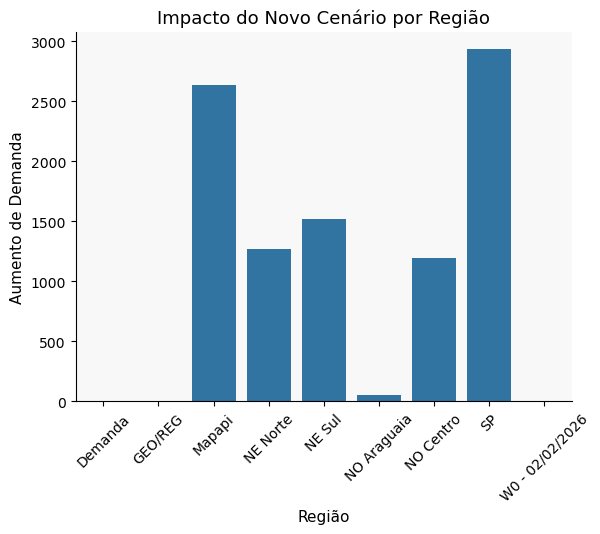

In [42]:
impacto_regiao = (
    df_novo.groupby("Região")["Demanda"].sum() -
    df_final.groupby("Região")["Demanda"].sum()
).reset_index()

impacto_regiao.columns = ["Região", "Impacto"]

plt.figure()
sns.barplot(data=impacto_regiao, x="Região", y="Impacto")
plt.title("Impacto do Novo Cenário por Região")
plt.xlabel("Região")
plt.ylabel("Aumento de Demanda")
plt.xticks(rotation=45)
plt.show()


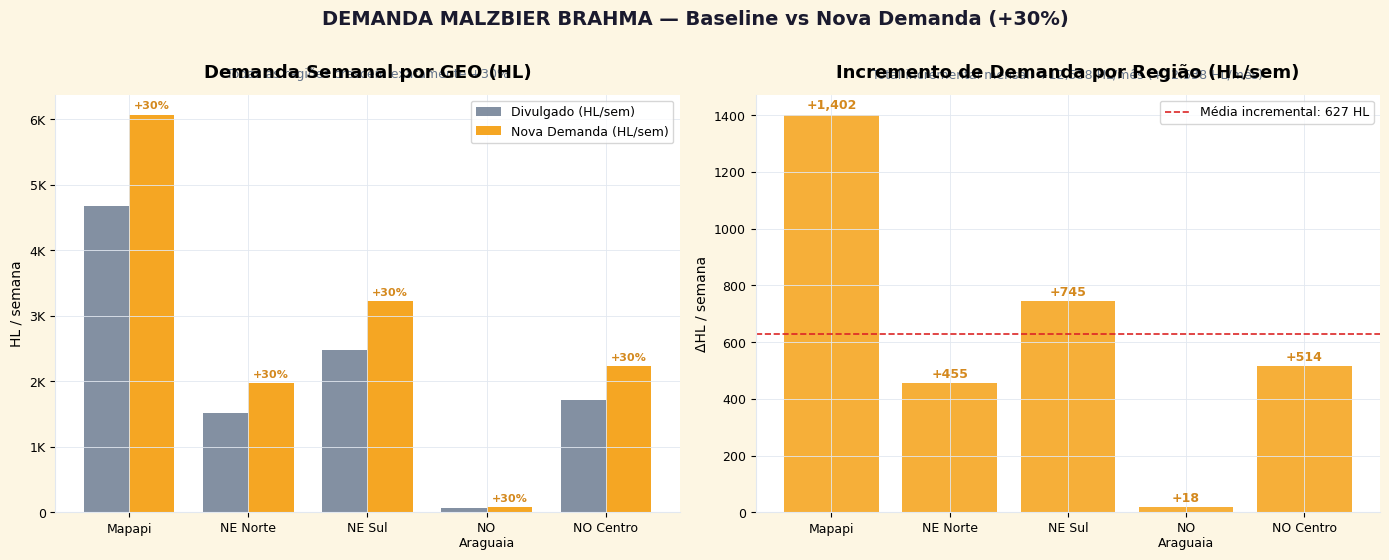

In [48]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

DARK="#1A1A2E"; AMBER="#F5A623"; AMBER2="#D4891E"; CREAM="#FDF6E3"
GRAY="#64748B"; RED="#DC2626"; LGRAY="#E2E8F0"; WHITE="#FFFFFF"

plt.rcParams.update({
    "figure.facecolor": CREAM, "axes.facecolor": WHITE,
    "axes.edgecolor": LGRAY, "axes.grid": True, "grid.color": LGRAY,
    "grid.linewidth": 0.6, "font.family": "DejaVu Sans",
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlepad": 12,
    "axes.labelsize": 10, "xtick.labelsize": 9, "ytick.labelsize": 9,
    "legend.fontsize": 9,
})

regioes  = ["Mapapi", "NE Norte", "NE Sul", "NO\nAraguaia", "NO Centro"]
base_sem = [4672.9, 1516.7, 2484.9, 60.7, 1713.5]
nova_sem = [6074.8, 1971.8, 3230.3, 78.9, 2227.5]
delta_sem = [n - b for n, b in zip(nova_sem, base_sem)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.patch.set_facecolor(CREAM)
fig.suptitle("DEMANDA MALZBIER BRAHMA — Baseline vs Nova Demanda (+30%)",
             fontsize=14, fontweight="bold", color=DARK, y=1.01)

ax = axes[0]
x = np.arange(len(regioes)); w = 0.38
ax.bar(x - w/2, base_sem, w, label="Divulgado (HL/sem)", color=GRAY, alpha=0.8)
bars2 = ax.bar(x + w/2, nova_sem, w, label="Nova Demanda (HL/sem)", color=AMBER)
for b in bars2:
    ax.annotate("+30%", xy=(b.get_x()+b.get_width()/2, b.get_height()),
                xytext=(0, 4), textcoords="offset points",
                ha="center", fontsize=8, color=AMBER2, fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(regioes)
ax.set_title("Demanda Semanal por GEO (HL)")
ax.set_ylabel("HL / semana"); ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x/1000:.0f}K" if x>=1000 else f"{x:.0f}"))
ax.text(0.5, 1.04, "Todas as regiões crescem exatamente +30%",
        transform=ax.transAxes, fontsize=9, color=GRAY, ha="center")

ax2 = axes[1]
bars3 = ax2.bar(regioes, delta_sem, color=AMBER, alpha=0.9)
for b, d in zip(bars3, delta_sem):
    ax2.text(b.get_x()+b.get_width()/2, b.get_height()+20,
             f"+{d:,.0f}", ha="center", fontsize=9, fontweight="bold", color=AMBER2)
ax2.set_title("Incremento de Demanda por Região (HL/sem)")
ax2.set_ylabel("ΔHL / semana")
total_delta = sum(delta_sem)
ax2.axhline(total_delta/len(delta_sem), color=RED, linestyle="--", lw=1.2,
            label=f"Média incremental: {total_delta/len(delta_sem):,.0f} HL")
ax2.legend()
ax2.text(0.5, 1.04, f"Total incremental mensal: +{total_delta*4:,.0f} HL/mês (+12.538 HL/mês)",
         transform=ax2.transAxes, fontsize=9, color=GRAY, ha="center")

plt.tight_layout()
plt.savefig("fig1_demanda.png", dpi=160, bbox_inches="tight", facecolor=CREAM)
plt.show()